# Flappy Bird AI

* Objective: Train an AI agent to learn optimal jumping behavior in Flappy Bird.
* Goal metric: Train the bird to go past 100 pipes
* Why This Problem: Demonstrates decision-making under dynamic environment constraints. Also seems like a simple problem to understand neuroevolution.

# Training Strategy
* Method: Neuroevolution
* Reward function:
  1. +1 per frame survived
  2. +100 per pipe crossed
  3. -1000 on death
* Hyperparameters: Mutation rate, Mutation strength, Population size
* Train / Test split: Both are tried out on random seeds, so that makes sure there is no pattern between each set of worlds generated.

# Environment and State representation
* State features used: Bird y position, velocity, distance from near pipe, pipe gap height.
* Action space: {Jump, do nothing}


Importing relevant modules

In [77]:
import numpy as np
import random
import cv2
import imageio

from IPython.display import HTML
from base64 import b64encode
import tensorflow as tf
import matplotlib.pyplot as plt

Defining the game constants

In [2]:
# CONSTANTS
GRAVITY = 0.6
PIPE_SPEED = -4
FLAP_SPEED = -3
MAX_FALL_SPEED = 10
PIPE_GAP_SIZE = 100
PIPE_WIDTH = 75
BIRD_X = 200
BIRD_RADIUS = 12
SCREEN_HEIGHT = 400
SCREEN_WIDTH = 600
MAX_PIPES = 100

initial_bird_y_position = 176
initial_bird_y_velocity = 0
initial_pipe_x = 400

MUTATION_RATE = 0.05
MUTATION_STRENGTH = 0.1

## Making the game first

In [3]:
# Generate and return a random pipe position
def spawn_pipe():
  gap = 50
  pipe_gap_top = random.randrange(gap, SCREEN_HEIGHT-PIPE_GAP_SIZE-gap)
  return pipe_gap_top

In [4]:
# Initialise a random state
def initial_state():
  return [
      initial_bird_y_position,   # bird y position
      initial_bird_y_velocity,   # bird y vel
      initial_pipe_x,            # pipe x
      spawn_pipe()               # pipe gap top
  ]

In [5]:
def update_pipe(state):
  _, _, pipe_x, pipe_gap_top = state
  new_pipe = False
  if pipe_x < 100:
    pipe_x = initial_pipe_x
    pipe_gap_top = spawn_pipe()
    new_pipe = True

  return (pipe_x, pipe_gap_top, new_pipe)

In [6]:
def update_state(state):
  bird_y, bird_y_vel, pipe_x, pipe_gap_top = state

  pipe_x, pipe_gap_top, new_pipe = update_pipe(state)

  bird_y_vel = min(bird_y_vel + GRAVITY, MAX_FALL_SPEED)
  bird_y += bird_y_vel
  pipe_x += PIPE_SPEED

  return [bird_y, bird_y_vel, pipe_x, pipe_gap_top], new_pipe

In [7]:
state = initial_state()
print(f"Initial state: {state}")
print(f"Updated state: {update_state(state)}")

Initial state: [176, 0, 400, 183]
Updated state: ([176.6, 0.6, 396, 183], False)


Defining the functions for the bird

In [8]:
def flap_bird(state):
  bird_y, bird_y_vel, pipe_x, pipe_gap_top = state
  bird_y_vel = FLAP_SPEED
  return [bird_y, bird_y_vel, pipe_x, pipe_gap_top]

Defining the score function

In [9]:
def update_score(score, new_pipe, death):
  score += 1
  if new_pipe:
    score += 100
  if death:
    score -= 1000

  return score

In [10]:
def check_death(state):
  bird_y, _, pipe_x, pipe_gap_top = state

  # Out of screen bounds
  if bird_y - BIRD_RADIUS < 0 or bird_y + BIRD_RADIUS > SCREEN_HEIGHT:
    # print('Off screen')
    return True

  # Pipe collision - Horizontal check
  if not (pipe_x > BIRD_X + BIRD_RADIUS or (pipe_x + PIPE_WIDTH) < BIRD_X - BIRD_RADIUS):
    # Pipe collision - Vertical check: bird's top edge < top_of_gap OR bird's bottom edge > bottom_of_gap
    if (bird_y - BIRD_RADIUS < pipe_gap_top or bird_y + BIRD_RADIUS > pipe_gap_top + PIPE_GAP_SIZE):
      # print('Colliding with pipe')
      return True

  return False

Defining functions for making a video of the game

In [11]:
def render_frame(state):
  # Breaking the state down
  bird_y, bird_vel, pipe_x, pipe_gap_top = state

  # Create a blank frame
  frame = np.zeros((SCREEN_HEIGHT, SCREEN_WIDTH, 3), dtype=np.uint8)

  # Sky
  frame[:] = (135, 206, 235)  # light blue

  # Draw bird
  cv2.circle(frame,
              (BIRD_X, int(bird_y)), # Use BIRD_X constant for x-coordinate
              BIRD_RADIUS, # Use the consistent BIRD_RADIUS
              (255, 255, 0),
              -1)

  # Draw pipe
  x = int(pipe_x)
  gap_y = int(pipe_gap_top) # Now gap_y is consistently the top edge of the gap

  # Top pipe
  cv2.rectangle(frame,
                (x, 0),
                (x+PIPE_WIDTH, gap_y), # Top pipe ends at gap_y
                (0, 255, 0),
                -1)

  # Bottom pipe
  cv2.rectangle(frame,
                (x, gap_y + PIPE_GAP_SIZE), # Bottom pipe starts at gap_y + PIPE_GAP_SIZE
                (x+PIPE_WIDTH, SCREEN_HEIGHT),
                (0, 255, 0),
                -1)

  return frame

In [12]:
def play_video(states, video_path="temp.mp4"):
  frames = [render_frame(state) for state in states]

  # Save video
  imageio.mimsave(
      video_path,
      frames,
      fps=30,
      codec="libx264"
  )

  # Embed video directly
  mp4 = open(video_path, 'rb').read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

  return HTML(f"""
  <video width=400 controls>
        <source src="{data_url}" type="video/mp4">
  </video>
  """)

In [13]:
state = initial_state()
states = [state]
print(f"Starting state: {state}")
for i in range(1000):
  state, _ = update_state(state)
  states.append(state)
  if check_death(state):
    print(f"Ending state: {state}")
    states.append(state)
    break

Starting state: [176, 0, 400, 178]
Ending state: [397.6, 10, 280, 178]


In [14]:
play_video(states)

Now that we have all the necessary functions for the flappy bird project, all that's left is to make the AI model that actually learns to play the game!

# Defining the necessary functions for the training
The training works as follows:
  * First we let the models play.
  * Once all the birds are done, we choose the elite birds out of the population.
  * These birds are then cloned and children are made out of similar mutated weights as that of the elite birds.
  * This new set of birds are made to play the game again and follow the cycle again.

In [15]:
def clone_model(model, initialize_model_fn):
  clone = initialize_model_fn()
  clone.set_weights(model.get_weights())
  return clone

This below code is responsible for mutating the weights of a given bird and use that as the weights for another bird. Essentially mutating the genes of one bird for a child.

In [16]:
def mutate(model):
  weights = model.get_weights()
  new_weights = []

  for w in weights:
    mask = np.random.rand(*w.shape) < MUTATION_RATE
    noise = np.random.normal(0, MUTATION_STRENGTH, size=w.shape)
    w = w + mask * noise
    new_weights.append(w)

  model.set_weights(new_weights)
  return model

Now let's define the function where we actually make the birds play and then from the next set of birds to train again for a number of epochs.

In [17]:
def train_birds(bird_models, initialize_model_fn, flap_cond, epochs=3, max_pipes=MAX_PIPES, number_of_birds=20, number_of_elite_birds=5):
  # The number of generations
  for epoch in range(epochs):
    print(f'\nTraining epoch: {epoch+1}/{epochs}\n')

    elite_birds = []
    bird_alive = [True] * number_of_birds
    bird_states = [initial_state() for _ in range(number_of_birds)]
    pipes = [0] * number_of_birds
    scores = np.array([0] * number_of_birds)

    while any(bird_alive):
      for i, model in enumerate(bird_models):
        # Do not let bird continue after death
        if not bird_alive[i]: continue

        state = bird_states[i]

        action = predict(model, state)
        # If the model tells to flap
        if flap_cond(action):
          state = flap_bird(state)

        # Updating the state per frame
        state, new_pipe = update_state(state)
        if new_pipe: pipes[i] += 1

        # Updating scores
        death = check_death(state) or pipes[i] >= max_pipes
        scores[i] = update_score(scores[i], new_pipe, death)
        if death:
          # print(f'Bird {i} is dead', end=f'. Score: {scores[i]}\n')
          bird_alive[i] = False

        # Updating the bird states
        bird_states[i] = state

    # Choosing the elite birds
    sorted_indices = np.argsort(scores)

    print(scores)
    print("Max score:", np.max(scores))
    print("Mean score:", np.mean(scores))

    for i in range(number_of_elite_birds):
      index = sorted_indices[-(i+1)]
      elite_bird = bird_models[index]
      elite_birds.append(elite_bird)

    # Creating the new population
    new_population = elite_birds.copy()
    while (len(new_population) < number_of_birds):
      parent = random.choice(elite_birds)
      child = mutate(clone_model(parent, initialize_model_fn))
      new_population.append(child)

    # Making the new population the current population
    bird_models = new_population.copy()

  return bird_models

Defining a function to normalize the state of the input as it helps in converging quicker

In [18]:
def normalize_state(state):
  bird_y, vel, pipe_x, gap = state
  return np.array([
    bird_y / SCREEN_HEIGHT,
    vel / MAX_FALL_SPEED,
    pipe_x / SCREEN_WIDTH,
    gap / SCREEN_HEIGHT
  ], dtype=np.float32)

In [19]:
@tf.function(reduce_retracing=True)
def _predict_tf(model, state):
    return model(state, training=False)

def predict(model, state):
    normalized_state = normalize_state(state)
    state = tf.convert_to_tensor(normalized_state, dtype=tf.float32)
    state = tf.expand_dims(state, axis=0)

    return _predict_tf(model, state)

Function to simulate how the model does in a random world

In [52]:
def perform(model, flap_cond):
  state = initial_state()
  states = [state]
  score = 0

  while (True):
      action = predict(model, state)
      if flap_cond(action):
        state = flap_bird(state)

      state, new_pipe = update_state(state)
      states.append(state)
      death = check_death(state)

      score = update_score(score, new_pipe, death)

      if death: break

  print(score)

  return states

# Model Architecture
The model will always have input of 4 neurons and output of 1 neuron. If the output is positive, the bird will flap, or it wont.

## 1. Defining a basic model first:
    * Input: 4 neurons
    * Hidden: 4 neurons (relu activation)
    * Output: 1 neuron

In [21]:
def initialize_neural_network_model_1():
  return tf.keras.Sequential([
      tf.keras.layers.Dense(4, input_shape=(4,), activation='relu'),
      tf.keras.layers.Dense(1)
  ])

def flap_cond(action):
  return action > 0

Testing if the model predicts some output according to given state

In [22]:
model_1 = initialize_neural_network_model_1()

state = initial_state()

for i in range(10):
  state, _ = update_state(state)
  action = model_1.predict(np.array(state)[np.newaxis, :])

  print(action)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
[[89.718506]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[88.67789]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[87.57053]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[86.39645]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[85.15563]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[83.84808]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[82.47382]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[81.03281]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[79.525085]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[77.950615]]


Let's make the first model play without any training and observe what it does

In [23]:
model_1 = initialize_neural_network_model_1()
states = perform(model_1, flap_cond)

-953


In [24]:
play_video(states)

Clearly the model needs to be trained to perform well...

In [25]:
# Let's train a batch of 50 birds
number_of_birds = 50
number_of_elite_birds = 10
initialize_model_fn = initialize_neural_network_model_1
epochs = 10

bird_models = [initialize_model_fn() for _ in range(number_of_birds)]

bird_models = train_birds(
    bird_models=bird_models,
    initialize_model_fn=initialize_model_fn,
    flap_cond=flap_cond,
    epochs=epochs,
    number_of_birds=number_of_birds,
    number_of_elite_birds=number_of_elite_birds
)


Training epoch: 1/10

[-953 -970 -953 -953 -970 -953  279 -953 -953 -953 -970 -970 -970 -953
 -933 -970 -953 -953 -953 -953 -970 -953 -953 -953 -970 -953 -953 -953
 -970 -953 -953 -970 -970 -970 -953 -953 -953 -953 -953 -953 -953 -953
 -777 -953 -953 -958 -957 -970 -970 -953]
Max score: 279
Mean score: -929.38

Training epoch: 2/10

[-601 -931 -937 -953 -953 -953 -953 -946 -953 -953 -953 -777 -777 -953
 -953 -953 -953 -953 -953 -953 -953 -970 -941 -953 -953 -953 -953 -953
 -945 -953 -953 -953 -777 -777 -953 -953 -953 -409 -953 -777 -953 -953
 -953 -953 -953 -953 -953 -953 -953 -953]
Max score: -409
Mean score: -916.52

Training epoch: 3/10

[-929  983 -953 -601 -777 -953 -425 -953 -953 -929 -952 -953 -953 -953
 -930 -953 -601 -953 2215 -953 -777 -425 -777 -933 -777 -941 -777 -771
 -947 -946 -777 -937 -953 -953 -953 -953 -425 -932 -777 -953 -953 -953
 -953 -775 -970 -953 -953 -953 -946 -953]
Max score: 2215
Mean score: -770.44

Training epoch: 4/10

[-249 -425 -777 -425 -933 -249 -777 

In [26]:
# The way the new batch is made so that the first bird was the best last batch
model_1 = bird_models[0]
states = perform(model_1, flap_cond)
play_video(states)

-777


Well this isn't doing that good even though enough birds are given and enough epochs are given...

We can see how the mean is fluctuating between one value, so it's not going to perform any better if we train it more with bigger amount of birds or more epochs. So we can now modify the model itself.

Let's now make another model which uses sigmoid activation to choose between binary options.

## 2. Making it a binary cross entropy based model:
    * Input: 4 neurons
    * Hidden: 4 neurons (relu activation)
    * Output: 1 neuron (sigmoid activation)

In [27]:
def initialize_neural_network_model_2():
  return tf.keras.Sequential([
      tf.keras.layers.Dense(4, input_shape=(4,), activation='relu'),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])

def flap_cond2(action):
  return action > 0.5

In [32]:
# Let's train a batch of 50 birds with this new model now
number_of_birds = 50
number_of_elite_birds = 10
initialize_model_fn = initialize_neural_network_model_2
epochs = 10

bird_models = [initialize_model_fn() for _ in range(number_of_birds)]

bird_models = train_birds(
    bird_models=bird_models,
    initialize_model_fn=initialize_model_fn,
    flap_cond=flap_cond2,
    epochs=epochs,
    number_of_birds=number_of_birds,
    number_of_elite_birds=number_of_elite_birds
)


Training epoch: 1/10

[-953 -970 -942 -953 -953 -953 -970 -953 -953 -953 -953 -777 -970 -953
 -970 -970 -970 -970 -953 -953 -953 -953 -953 -953 -953 -953 -953 -970
 -953 -777 -970 -953 -970 -953 -953 -953 -970 -953 -970 -953 -970 -953
 -953 -970 -970 -970 -953 -970 -953 -970]
Max score: -777
Mean score: -951.86

Training epoch: 2/10

[-931 -953 -601 -953 -953 -953 -953 -953 -953 -953 -953 -953 -950 -953
 -953 -953 -777 -953 -953 -953 -941 -940 -953 -933 -958 -932 -953 -953
 -953 -777 -953 -779 -953 -953 -953 -941 -957 -953 -953 -953 -953 -970
 -953 -953 -953 -953 -953 -777 -777 -953]
Max score: -601
Mean score: -926.86

Training epoch: 3/10

[-953 -777 -777 -953 -777 -953 -591 -597 -953 -936 -579 -953 -953 -953
 -953 -941 -957 -408 -777 -772 -953 -947 -777 -953 -601 -953 -777 -935
 -777 -938 -777 -953 -425 -953 -953 -952 -601 -939 -765 -945 -577 -942
 -952 -777 -938 -942 -953 -777 -949 -759]
Max score: -408
Mean score: -839.06

Training epoch: 4/10

[-753 -933 -773 -767 -944 -777 -777

These seem to look like good outputs

In [34]:
states = perform(bird_models[0], flap_cond2)
play_video(states)

-66


This performed so much better, it has learnt the pattern of when to flap and not much better than the first model already.
The mean also grew constantly, only in the last epoch the mean dropped.. maybe its reaching it's saturation point so right now even if we train more models, it would improve, but not very drastically.

## 3. Making the model with tanh activation
    * Input: 4 neurons
    * Hidden: 4 neurons (tanh activation)
    * Output: 1 neuron (tanh activation)


Now we are changing the model to have a tanh activation in both the hidden and output layer. There are reasons for both the layers:

  * We change the activation of the hidden layer from 'relu' to 'tanh' because relu gets sorta stuck in neuroevolution. Basically, during gradient descend, if a neuron gets such weights so that relu gives output 0 due to negative input, it can be fixed due to backprop that fixes the gradients if this neurons holds some features that are important for the output of the model. Whereas, here in neuroevolution, there is no back propagation. That means there is no meaningful way to change weights, its through mutation and could end up getting the particular neurons stuck giving 0 output due to the weights. Hence changing it to a tanh activation would make sure both negative and positive input have outputs and different ones.

  * The reason for changing the output is not really anything too serious, but tanh is symmetrical at zero. So we can sort of make a region about the zero line itself and tell the more positive the output, the situation requires a flap, and the more negative the output, the situation requires to not flap and let it be.

Let's first change the model to not use keras as we are not really using any of keras properties and it's just slowing down the process of predicting.

### Redefining some of the necessary training functions

In [35]:
def predict_batch_model3(brains, states):
    W1 = np.stack([b['W1'] for b in brains])  # (N, 4, 4)
    b1 = np.stack([b['b1'] for b in brains])  # (N, 4)
    W2 = np.stack([b['W2'] for b in brains])  # (N, 4, 1)
    b2 = np.stack([b['b2'] for b in brains])  # (N, 1)

    # Forward pass — fully vectorized, no loop
    x = np.tanh(np.einsum('ni,nij->nj', states, W1) + b1)  # (N, 4)
    out = np.tanh(np.einsum('ni,nij->nj', x, W2) + b2)     # (N, 1)

    return out[:, 0]  # (N,) — one action per bird

Redefining the mutate and clone functions for the custom model

In [36]:
def mutate_brain(brain, mutation_rate=MUTATION_RATE, mutation_strength=MUTATION_STRENGTH):
    new_brain = {}
    for k, w in brain.items():
        mask = np.random.rand(*w.shape) < mutation_rate
        noise = np.random.randn(*w.shape).astype(np.float32) * mutation_strength
        new_brain[k] = w + mask * noise
    return new_brain

def clone_brain(brain):
    return {k: v.copy() for k, v in brain.items()}

We also need to modify the train function

In [59]:
def train_custom_birds(bird_brains, initialize_model_fn, flap_cond, epochs=3, max_pipes=MAX_PIPES, number_of_birds=20, number_of_elite_birds=5, mutation_rate=MUTATION_RATE, mutation_strength=MUTATION_STRENGTH):
    for epoch in range(epochs):
        print(f'\nTraining epoch: {epoch+1}/{epochs}\n')

        bird_alive = np.ones(number_of_birds, dtype=bool)
        bird_states = [initial_state() for _ in range(number_of_birds)]
        pipes = np.zeros(number_of_birds, dtype=int)
        scores = np.zeros(number_of_birds, dtype=int)

        while bird_alive.any():
            alive_indices = np.where(bird_alive)[0]

            # Batch normalize all alive states — single vectorized call
            states_matrix = np.array([
                normalize_state(bird_states[i]) for i in alive_indices
            ], dtype=np.float32)
            alive_brains = [bird_brains[i] for i in alive_indices]

            # One forward pass for ALL alive birds at once
            actions = predict_batch_model3(alive_brains, states_matrix)

            for idx, i in enumerate(alive_indices):
                # Flap if model says so
                if flap_cond(actions[idx]):
                    bird_states[i] = flap_bird(bird_states[i])

                # Step the simulation
                bird_states[i], new_pipe = update_state(bird_states[i])
                if new_pipe:
                    pipes[i] += 1

                death = check_death(bird_states[i]) or pipes[i] > max_pipes
                scores[i] = update_score(scores[i], new_pipe, death)

                if death:
                    bird_alive[i] = False

        # Elite selection
        sorted_indices = np.argsort(scores)
        print(scores)
        print("Max score:", np.max(scores))
        print("Mean score:", np.mean(scores))

        elite_brains = [bird_brains[sorted_indices[-(i+1)]] for i in range(number_of_elite_birds)]

        # Build next generation
        new_population = [clone_brain(b) for b in elite_brains]
        while len(new_population) < number_of_birds:
            parent = random.choice(elite_brains)
            new_population.append(mutate_brain(clone_brain(parent), mutation_rate=mutation_rate, mutation_strength=mutation_strength))

        bird_brains = new_population

    return bird_brains

Making a perform function as well

In [57]:
def perform_custom(brain, predict_fn, flap_cond):
    state = initial_state()
    states = [state]
    score = 0
    pipes = 0

    while True:
        state_matrix = np.array([normalize_state(state)], dtype=np.float32)
        action = predict_fn([brain], state_matrix)[0]

        if flap_cond(action):
            state = flap_bird(state)

        state, new_pipe = update_state(state)
        states.append(state)

        if new_pipe:
            pipes += 1

        death = check_death(state) or pipes > MAX_PIPES
        score = update_score(score, new_pipe, death)

        if death:
            break

    print(score)
    return states

### Continuing to use the new functions with the newly defined model

In [39]:
def initialize_custom_neural_network_model_3():
  input_neurons = 4
  hidden_neurons = 4
  output_neurons = 1

  return {
      'W1': np.random.randn(input_neurons, hidden_neurons).astype(np.float32) * 0.1,
      'b1': np.zeros(hidden_neurons, dtype=np.float32),
      'W2': np.random.randn(hidden_neurons, output_neurons).astype(np.float32) * 0.1,
      'b2': np.zeros(output_neurons, dtype=np.float32),
  }

def flap_cond3(action):
  return action > 0

Let's also bump up the number of elite birds from 10 to 15 to keep some genetic diversity. Does not act too harsh on the birds.

In [40]:
# Let's train a batch of 50 birds with this new model now
number_of_birds = 50
number_of_elite_birds = 15
initialize_model_fn = initialize_custom_neural_network_model_3
epochs = 20

bird_models = [initialize_model_fn() for _ in range(number_of_birds)]

bird_models = train_custom_birds(
    bird_brains=bird_models,
    initialize_model_fn=initialize_model_fn,
    flap_cond=flap_cond3,
    epochs=epochs,
    number_of_birds=number_of_birds,
    number_of_elite_birds=number_of_elite_birds
)


Training epoch: 1/20

[-970 -970 -943 -953 -953 -970 -953 -970 -953 -953 -953 -953 -953 -953
 -953 -953 -953 -953 -970 -970 -953 -970 -953 -953 -953 -970 -970 -953
 -953 -952 -970 -953 -953 -970 -970 -970 -970 -777 -970 -952 -943 -970
 -953 -970 -777 -953 -953 -944 -953 -953]
Max score: -777
Mean score: -951.12

Training epoch: 2/20

[-953 -425 -953 -763 -953 -953 -953 -953 -953 -953 -970 -953 -953 -953
 -953 -953 -953 -953 -953 -953 -953 -970 -953 -953 -953 -953 -970 -953
 -970 -953 -777 -970 -953 -953 -953 -953 -953 -953 -953 -953 -957 -953
 -953 -953 -970 -953 -953 -953 -970 -953]
Max score: -425
Mean score: -937.58

Training epoch: 3/20

[-953 -959 -777 -953 -953 -953 -953 -953 -953 -953 -953 -953 -953 -953
 -945 -953 -777 -953 -953 -953 -950 -953 -953 -953 -953 -953 -953 -953
 -953 -953 -953 -953 -953 -953 -953 -953 -953 -953 -953 -953 -953 -953
 -953 -953 -953 -953 -953 -970 -953 -953]
Max score: -777
Mean score: -946.2

Training epoch: 4/20

[-936 -601 -948 -953 -953 -953 -777 

Here we see that the model has sort of saturated, let's try to use higher mutation to make it so that the model can escape the generalisation of the specie.

Also before retrying to run the model and check how it performs, let's make the normalized state function a bit better. Let's make it so that the state that the model receives is not just the top position of the pipe, but instead it is the relative position of the pipe's center from the bird's y position.

I'm doing this because in gradient descend, it's much more easier to form implicit relationships in the model due to meaningful changes to the weights, but here it's random, it has to basically form this connection to luck. So instead, we can help it with this by letting it know if the pipe center is too high, or too low from it's current position

In [41]:
def normalize_state(state):
    bird_y, vel, pipe_x, gap_top = state
    gap_center = gap_top + PIPE_GAP_SIZE / 2
    return np.array([
        bird_y / SCREEN_HEIGHT,
        vel / MAX_FALL_SPEED,
        pipe_x / SCREEN_WIDTH,
        (bird_y - gap_center) / SCREEN_HEIGHT,  # negative = above gap, positive = below
    ], dtype=np.float32)

In [42]:
# First let's see how much this normalizing itself helps improve the model's convergence.
# Also let's reduce the number of elite birds because it became a bit too easy for the birds to be able to be considered 'elite'
number_of_birds = 50
number_of_elite_birds = 10
initialize_model_fn = initialize_custom_neural_network_model_3
epochs = 20

bird_models = [initialize_model_fn() for _ in range(number_of_birds)]

bird_models = train_custom_birds(
    bird_brains=bird_models,
    initialize_model_fn=initialize_model_fn,
    flap_cond=flap_cond3,
    epochs=epochs,
    number_of_birds=number_of_birds,
    number_of_elite_birds=number_of_elite_birds
)


Training epoch: 1/20

[-953 -953 -953 -970 -953 -953 -953 -952 -953 -953 -953 -970 -970 -970
 -953 -953 -953 -953 -777 -970 -953 -970 -930 -953 -777 -970 -777 -953
 -953 -953 -970 -970 -970 -953 -970 -953 -936 -953 -953 -970 -953 -953
 -970 -953 -970 -970 -953 -970 -970 -970]
Max score: -777
Mean score: -947.74

Training epoch: 2/20

[-953 -777 -953 -953 -935 -953 -953 -953 -953 -953 -953 -970 -953 -953
 -777 -953 -936 -953 -953 -953 -953 -953 -953 -953 -953 -953 -777 -953
 -773 -953 -777 -953 -949 -953 -953 -953 -953 -953 -970 -970 -953 -953
 -953 -953 -970 -953 -953 -953 -953 -953]
Max score: -773
Mean score: -935.9

Training epoch: 3/20

[-953 -953 -953 -777 -953 -953 -953 -953 -951 -953 -953 -947 -953 -970
 -953 -970 -936 -953 -953 -949 -934 -953 -777 -949 -951 -938 -601 -953
 -939 -944 -953 -953 -777 -953 -953 -953 -953 -601 -953 -953 -953 -951
 -777 -953 -953 -777 -597 -953 -953 -777]
Max score: -597
Mean score: -909.48

Training epoch: 4/20

[-777 -953 -953 -953 -953 -953 -951 

So many birds are getting full score at this point 🎉🎉

Let's change the video function to show a pipe counter as well as have a playback speed to make sure it doesn't take too much time to load the video.

In [43]:
def render_frame(state, pipes_crossed=0):
    bird_y, bird_vel, pipe_x, pipe_gap_top = state

    frame = np.zeros((SCREEN_HEIGHT, SCREEN_WIDTH, 3), dtype=np.uint8)
    frame[:] = (135, 206, 235)

    # Draw bird
    cv2.circle(frame, (BIRD_X, int(bird_y)), BIRD_RADIUS, (255, 255, 0), -1)

    # Draw pipes
    x = int(pipe_x)
    gap_y = int(pipe_gap_top)
    cv2.rectangle(frame, (x, 0), (x + PIPE_WIDTH, gap_y), (0, 255, 0), -1)
    cv2.rectangle(frame, (x, gap_y + PIPE_GAP_SIZE), (x + PIPE_WIDTH, SCREEN_HEIGHT), (0, 255, 0), -1)

    # Pipe counter
    cv2.putText(frame,
                f"Pipes: {pipes_crossed}",
                (10, 30),                   # top left corner
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,                        # font scale
                (255, 255, 255),            # white text
                2,                          # thickness
                cv2.LINE_AA)

    return frame


def play_video(states, video_path="temp.mp4", playback_speed=1):
    # Compute pipe crossings per frame so render_frame knows the count
    pipes_crossed = 0
    pipe_counts = []
    prev_pipe_x = states[0][2]

    for state in states:
        curr_pipe_x = state[2]
        # Pipe resets from near 100 back to initial_pipe_x — means a new pipe was crossed
        if curr_pipe_x > prev_pipe_x:
            pipes_crossed += 1
        pipe_counts.append(pipes_crossed)
        prev_pipe_x = curr_pipe_x

    # Skip frames according to playback_speed — speed=2 keeps every 2nd frame, etc.
    selected = list(range(0, len(states), playback_speed))
    frames = [render_frame(states[i], pipe_counts[i]) for i in selected]

    # FPS stays at 30 but fewer frames = shorter video = faster playback
    imageio.mimsave(video_path, frames, fps=30, codec="libx264")

    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

    return HTML(f"""
    <video width=400 controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    """)

Let's watch the bird play the whole game hopefully

In [45]:
states = perform_custom(bird_models[0], predict_batch_model3, flap_cond3)
play_video(states, playback_speed=4)

5031


There is a scenario where the model doesn't get enough time to reach the pipe because the x distance is too less even if it flaps the whole time, so let's increase the distance by a bit so that the bird get's enough time and retrain this model to learn that.

In [46]:
initial_pipe_x = 450

In [69]:
# First let's see how much this normalizing itself helps improve the model's convergence.
# Also let's reduce the number of elite birds because it became a bit too easy for the birds to be able to be considered 'elite'
number_of_birds = 50
number_of_elite_birds = 10
initialize_model_fn = initialize_custom_neural_network_model_3
epochs = 20

bird_models = [initialize_model_fn() for _ in range(number_of_birds)]

bird_models = train_custom_birds(
    bird_brains=bird_models,
    initialize_model_fn=initialize_model_fn,
    flap_cond=flap_cond3,
    epochs=epochs,
    number_of_birds=number_of_birds,
    number_of_elite_birds=number_of_elite_birds
)


Training epoch: 1/20

[-940 -940 -970 -940 -940 -940 -752 -940 -940 -926 -940 -940 -970 -940
 -970 -970 -940 -970 -940 -940 -940 -970 -940 -970 -940 -940 -752 -940
 -940 -970 -940 -940 -940 -940 -940 -940 -940 -940 -940 -940 -970 -970
 -940 -940 -948 -970 -564 -940 -970 -940]
Max score: -564
Mean score: -932.04

Training epoch: 2/20

[-752 -752 -374 -940 -940 -940 -940 -940 -940 -940 -940 -939 -940 -940
 -940 -940 -940 -930 -940 -940 -940 -940 -940 -940 -940 -940 -940 -940
 -940 -940 -940 -935 -752 -940 -940 -940 -940 -940 -940 -940 -940 -940
 -940 -940 -940 -940 -970 -970 -940 -940]
Max score: -374
Mean score: -918.28

Training epoch: 3/20

[-936 -940 -752 -940 -940 -930 -752 -940 -940 -940 -940 -940 -929 -928
 -970 -938 -752 -936 -940 -940 -940 -940 -940 -940 -939 -940 -940 -752
 -940 -940 -940 -940 -940 -940 -940 -940 -939 -919 -940 -940 -940 -940
 -940 -931 -940 -934 -940 -940 -940 -940]
Max score: -752
Mean score: -923.94

Training epoch: 4/20

[-940 -938 -924 -752 -919 -940 -928

Look's like this is the actual highest score?

## 4. Lets make the mean score of the specie higher
Now that the model is able to reach the max score according to the game constants and limitations, there are still birds in the last generation from training that dont actually reach the potential highest they can, so lets train the current birds for 30 more epochs to see the mean score of all birds reach a much higher value. Let's also tighten up the mutation to make sure the birds do not explore too much as they are now at the right point.

In [74]:
epochs = 20
bird_models = train_custom_birds(
    bird_brains=bird_models,
    initialize_model_fn=initialize_model_fn,
    flap_cond=flap_cond3,
    epochs=epochs,
    number_of_birds=number_of_birds,
    number_of_elite_birds=number_of_elite_birds,
    mutation_rate=0.04,
    mutation_strength=0.8
)


Training epoch: 1/20

[17989 17989 17989 17989 17989 17989 17989 17989 17989 17989 17989 17989
 17989  -750 17989 17989  -926 17989 17989 17989 17989 17989  7708 17989
 17989 12596 17989 17989 17989  -564  3572 17989 10716  -940  -541 17989
  -970  -940  5288 17989  -940 17989  -940 17989 17989 17989 17989 17989
 17989 17506]
Max score: 17989
Mean score: 13589.8

Training epoch: 2/20

[17989 17989 17989 17989 17989 17989 17989 17989 17989 17989 17989 17989
 17989  -970 17989 17989 17989 17989 17989  -970 17989  -970 17989 17989
 17989  2260  5452 17989 17989 17989 17989 17989 17989   588 17989 17989
 15416  -970  -749 17989 17989 17989 17989 17989 17989  -940 17989  8836
 17989  -970]
Max score: 17989
Mean score: 14191.9

Training epoch: 3/20

[17989 17989 17989 17989 17989  3948 17989 17989 17989 17989  -970  -940
  -940  -940  -970 17989 17989  -559  -940 17989 17989 17989 17989 17989
 17989 17989 17989 17989 17989    12  -970  -940  -188 17989  -940 17989
 17989 17989 17989 17989 1

Now we can see that most of the birds are performing good at this task and are having an average score of around 13000. Which is really good for the model.

# Results

The model reached the theoritical max score of 17989, which means the final model learnt to cross a 100 pipes.

| Model | Architecture | Key Change | Best Score | Mean Score (final epoch) |
| :--- | :--- | :--- | :--- | :--- |
| Model 1 | 4 -> 4(RelU) -> 1(Linear)  | Baseline              | 3095 | -326.0 |
| Model 2 | 4 -> 4(RelU) -> 1(Sigmoid) | Sigmoid output        | 11884 | -775.16 |
| Model 3 | 4 -> 4(Tanh) -> 1(Tanh)    | Tanh + Numpy batching | 17989 | 13839.32 |


Let's plot the graphs for the training of the models to see their scores growth

In [81]:
def plot(mean_scores, max_scores, title):
  plt.figure(figsize=(12, 4))
  plt.plot(mean_scores, label='Mean score', color='steelblue')
  plt.plot(max_scores, label='Max score', color='orange', linestyle='--')
  plt.axhline(y=17989, color='green', linestyle=':', label='Theoretical max (17989)')
  plt.xlabel('Epoch')
  plt.ylabel('Score')
  plt.title(title)
  plt.legend()
  plt.tight_layout()
  plt.show()

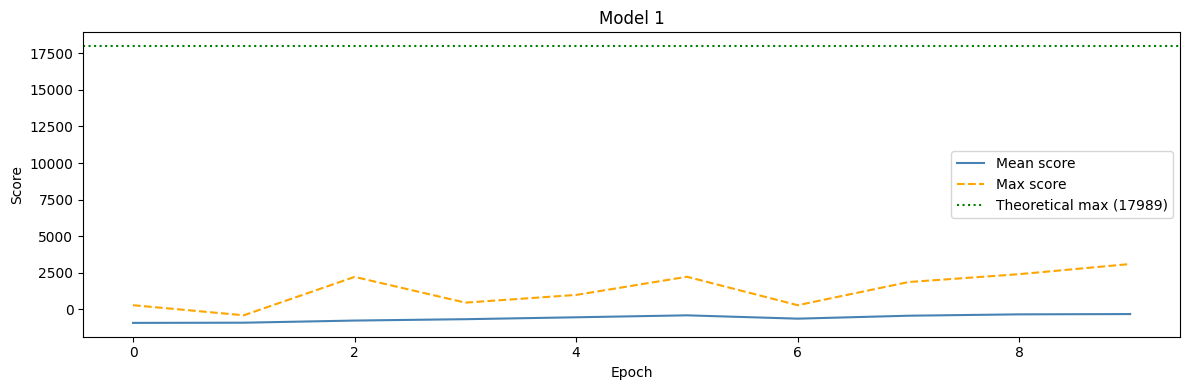

In [87]:
mean_scores_m1 = [
    -929.38, -916.52, -770.44, -676.78, -546.66,
    -413.1, -640.46, -438.86, -346.06, -326.0
]

max_scores_m1 = [
    279, -409, 2215, 455, 983,
    2224, 279, 1863, 2402, 3095
]

plot(mean_scores_m1, max_scores_m1, 'Model 1')

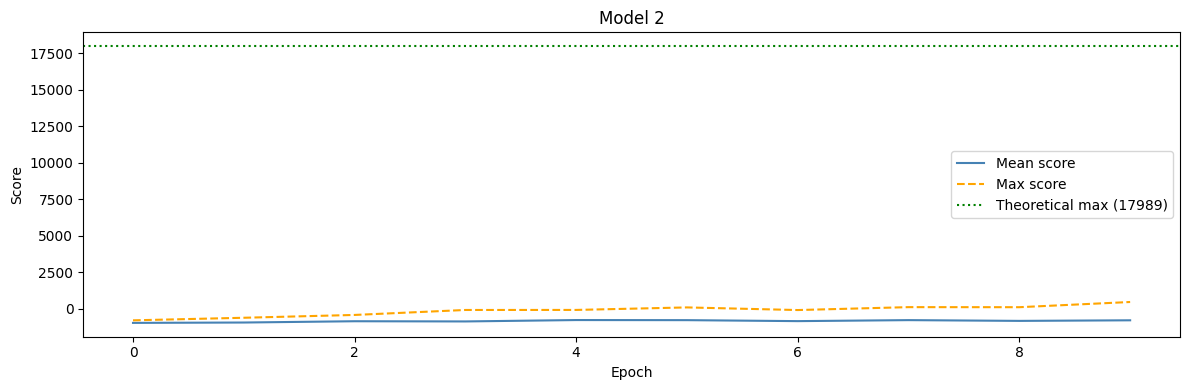

In [88]:
mean_scores_m2 = [
    -951.86, -926.86, -839.06, -852.96, -758.0,
    -764.94, -831.54, -763.14, -815.02, -775.16
]

max_scores_m2 = [
    -777, -601, -408, -68, -65,
    107, -73, 126, 122, 478
]

plot(mean_scores_m2, max_scores_m2, 'Model 2')

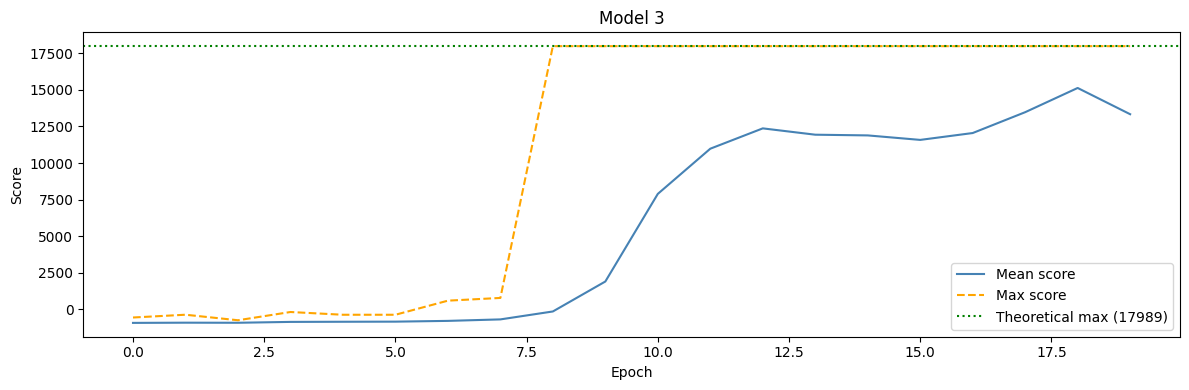

In [89]:
mean_scores_m3 = [
    -932.04, -918.28, -923.94, -864.78, -854.84,
    -847.24, -795.18, -693.58, -151.52, 1897.56,
    7889.1, 10978.34, 12368.48, 11935.52, 11887.06,
    11580.14, 12049.32, 13474.66, 15130.48, 13336.22
]

max_scores_m3 = [
    -564, -374, -752, -188, -376,
    -376, 588, 774, 17989, 17989,
    17989, 17989, 17989, 17989, 17989,
    17989, 17989, 17989, 17989, 17989
]

plot(mean_scores_m3, max_scores_m3, 'Model 3')

# Key Learnings

* **Feature engineering**: Learnt that it would be much better to give the bird the value of how high or low the center of the pipe is relative to it's y position. This was done because I understood that in neuroevolution, making an implicit connection between different inputs is harder and more luck based in comparison to gradient descend. Hence it would be a favour to provide the relative position of the bird's y and the pipe's center instead of letting the bird find that out on it's own

* **Activation function**: Tanh activation is much better for neuroevolution than RelU function. This is because tanh is more symmetrical about zero line and does not completely nullify the output to zero if the input is negative. This also can act as the activation function for the output layer as it gives positive and negative output symmetrically as well.

* **Vectorisation**: It was better to make custom models using numpy instead of looping through each model and predicting it's output. This is because all the models' output can be calculated at once which is much quicker than looping one by one and then calculating their outputs. Also it was better to do it on my own than using Keras models later onwards as we dont really use any of their complex functions and numpy could be used here for quicker training epochs.

* **Model Size**: The problem is solvable with just 25 parameters (4×4 + 4 + 4×1 + 1) — model capacity was never the bottleneck

# Final model playing the game till the end


In [70]:
states = perform_custom(bird_models[0], predict_batch_model3, flap_cond3)
play_video(states, playback_speed=6)

17989
